# Figure 6: SCD - MCSS Breakdown 

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

## SCD

In [4]:
df1 = pd.read_csv(f"../bench_results_mcscan_fp16_128_fp16.csv")
df2 = pd.read_csv(f"../bench_results_compress_128_0.001_fp32.csv")
df3 = pd.read_csv(f"../bench_results_diff_cann_fp32.csv")

segsum_dataframe = pd.concat([df1, df2, df3], ignore_index=True)
segsum_dataframe["time_ms"] = segsum_dataframe["time_us"].astype(float) / 1000.0
segsum_dataframe.head()


,operator,dtype,size,density,outputsize,time_us,time_ms
0,mcscan_fp16_128,fp16,327680,NaN,327680,130.13,0.13013
1,mcscan_fp16_128,fp16,5570560,NaN,5570560,231.55,0.23155
2,mcscan_fp16_128,fp16,10813440,NaN,10813440,341.15,0.34115
3,mcscan_fp16_128,fp16,16056320,NaN,16056320,453.71,0.45371
4,mcscan_fp16_128,fp16,21299200,NaN,21299200,569.69,0.56969


<Figure size 1100x800 with 0 Axes>

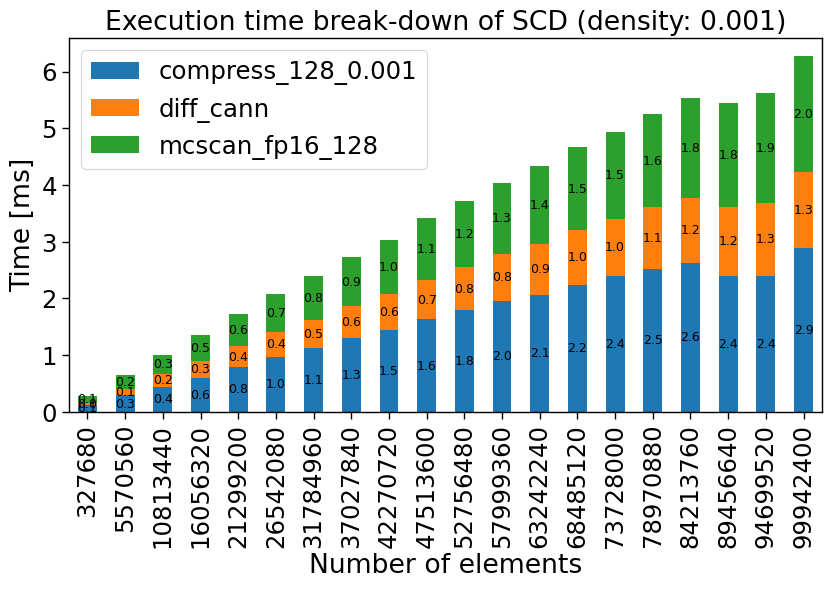

In [5]:
plt.figure(figsize=(11, 8))

pivot_df = segsum_dataframe.pivot(index='size', columns='operator', values='time_ms')
ax = pivot_df.plot(kind='bar', stacked=True)

plt.xlabel('Number of elements')
plt.ylabel('Time [ms]')
plt.title('Execution time break-down of SCD (density: 0.001)')
plt.legend(loc="upper left")
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='center', color='black', fontsize=9)

plt.savefig("scd_time_breakdown.pdf", bbox_inches='tight')
plt.show()

## MCSS

In [6]:
df4 = pd.read_csv(f"../bench_results_mcscan_fp16_128_fp16.csv")
df5 = pd.read_csv(f"../bench_results_mcscan_int8_128_int8.csv")
df6 = pd.read_csv(f"../bench_results_compress_128_0.001_fp32.csv")
df7 = pd.read_csv(f"../bench_results_seg_scan_mc_revert_fp32.csv")


segscan_dataframe = pd.concat([df4, df5, df6, df7], ignore_index=True)
segscan_dataframe["time_ms"] = segscan_dataframe["time_us"].astype(float) / 1000.0
segscan_dataframe.head()


,operator,dtype,size,density,outputsize,time_us,time_ms
0,mcscan_fp16_128,fp16,327680,NaN,327680,130.13,0.13013
1,mcscan_fp16_128,fp16,5570560,NaN,5570560,231.55,0.23155
2,mcscan_fp16_128,fp16,10813440,NaN,10813440,341.15,0.34115
3,mcscan_fp16_128,fp16,16056320,NaN,16056320,453.71,0.45371
4,mcscan_fp16_128,fp16,21299200,NaN,21299200,569.69,0.56969


<Figure size 1100x800 with 0 Axes>

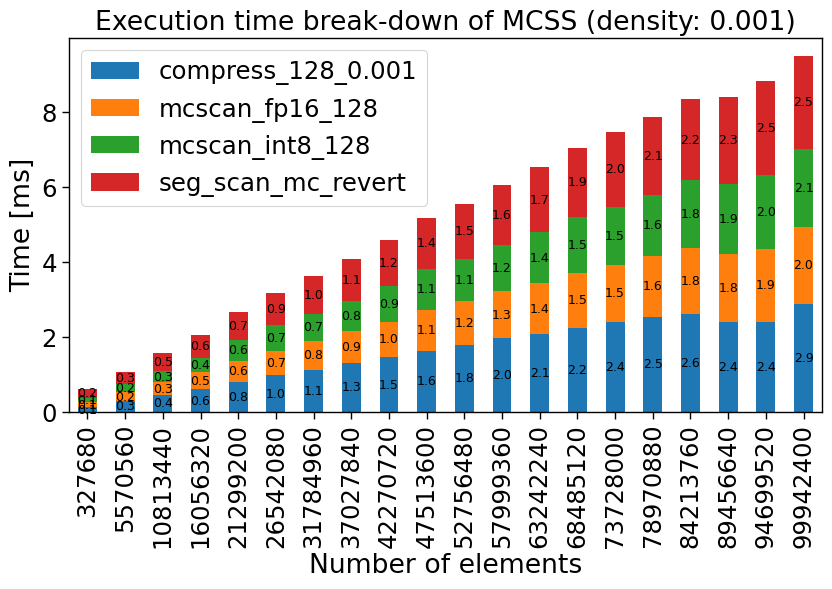

In [ ]:
plt.figure(figsize=(11, 8))

pivot_df = segscan_dataframe.pivot(index='size', columns='operator', values='time_ms')
ax = pivot_df.plot(kind='bar', stacked=True)

plt.xlabel('Number of elements')
plt.ylabel('Time [ms]')
plt.title('Execution time break-down of MCSS (density: 0.001)')
plt.legend(loc="upper left")
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='center', color='black', fontsize=9)

plt.savefig("mcss_time_breakdown.pdf",bbox_inches='tight')



In [13]:
segscan_dataframe.head(100)

,operator,dtype,size,density,outputsize,time_us,time_ms
0,mcscan_fp16_128,fp16,327680,NaN,327680,130.13,0.13013
1,mcscan_fp16_128,fp16,5570560,NaN,5570560,231.55,0.23155
2,mcscan_fp16_128,fp16,10813440,NaN,10813440,341.15,0.34115
3,mcscan_fp16_128,fp16,16056320,NaN,16056320,453.71,0.45371
4,mcscan_fp16_128,fp16,21299200,NaN,21299200,569.69,0.56969
...,...,...,...,...,...,...,...
75,seg_scan_mc_revert,fp32,78970880,0.001,78937,2091.94,2.09194
76,seg_scan_mc_revert,fp32,84213760,0.001,83693,2168.51,2.16851
77,seg_scan_mc_revert,fp32,89456640,0.001,89168,2313.05,2.31305
78,seg_scan_mc_revert,fp32,94699520,0.001,94224,2494.36,2.49436


## Combine Charts

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import EngFormatter

In [ ]:
pivot_df_mcss = segscan_dataframe.pivot(index='size', columns='operator', values='time_ms')
pivot_df_scd = segsum_dataframe.pivot(index='size', columns='operator', values='time_ms')

pivot_df_mcss = pivot_df_mcss.rename(columns={col: f'MCSS_{col}' for col in pivot_df_mcss.columns})
pivot_df_scd = pivot_df_scd.rename(columns={col: f'SCD_{col}' for col in pivot_df_scd.columns})

               #Compress   #ScanFP    
mcss_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  
scd_colors = ['#1f77b4', '#7f7f7f', '#ff7f0e'] 
              #Compress    #diff     #ScanFP

fig, ax = plt.subplots(figsize=(16, 8))

bar_width = 0.35
index = range(len(pivot_df_mcss))

bars_mcss = pivot_df_mcss.plot(kind='bar', stacked=True, width=bar_width, ax=ax, color=mcss_colors, position=1,edgecolor="black")
bars_scd = pivot_df_scd.plot(kind='bar', stacked=True, width=bar_width, ax=ax, color=scd_colors, position=0, edgecolor="black")

ax.set_xlabel('Number of elements')
ax.set_ylabel('Time [ms]')
ax.set_title('Execution time break-down of MCSS and SCD (density: 0.001)')
ax.set_xticks([x -0.19 + bar_width/ 2 for x in index])
list_ticks = []
num_list = []
engFormat = EngFormatter()
for n in pivot_df_mcss.index:
    num_list.append(f"{engFormat(n)}")
    list_ticks=[f"{s:.2e}" for s in num_list]
ax.set_xticklabels(list_ticks)

i=0
print(ax.containers)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='center', color='black', fontsize=9)

legend_labels = ["MC_Compress_fp32","MC_Scan_fp16","MC_Scan_int8","MC_RevertScan_fp32","MC_Diff_fp32"]
legend_colors = ["#1f77b4",'#ff7f0e','#2ca02c','#d62728','#7f7f7f']

legend_elements = [Patch(facecolor=legend_colors[i], label=legend_labels[i]) for i in range(5)]

ax.legend(handles=legend_elements, loc="upper left", frameon=False)

plt.savefig("unified_breakdowns.pdf", bbox_inches='tight')


SyntaxError: f-string: invalid syntax. Perhaps you forgot a comma? (1692617228.py, line 28)